In [1]:
# https://www.kaggle.com/api/v1/datasets/download/soylevbeytullah/house-prices-dataset

# Library Importation

import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt 


In [2]:
# data loading
data = pd.read_csv("kc_house_data.csv")
# dropping columns id and zipcode
data = data.drop(columns = ['date', 'id', 'waterfront', 'view'])
data.drop_duplicates(inplace=True) # sterge dublicatele
data = data.sort_values(by='zipcode').reset_index(drop=True)
data.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,551870.0,3,2.50,2507,18400,2.0,3,8,2507,0,2006,0,98001,47.2867,-122.270,1520,14709
1,182500.0,3,2.25,1830,4744,2.0,3,7,1830,0,1997,0,98001,47.2734,-122.248,1670,8001
2,290000.0,3,2.50,1600,6848,2.0,3,7,1600,0,2000,0,98001,47.3303,-122.271,1700,7210
3,264500.0,3,1.50,1580,14040,1.0,3,7,1050,530,1980,0,98001,47.2932,-122.267,2240,12000
4,205000.0,3,2.00,1410,8384,1.0,3,7,1410,0,1985,0,98001,47.3315,-122.263,1410,9205


In [3]:
# check if data is null
null = data.isnull().sum()
if null.sum() == 0:
    print('No null data')
else:
    print('null data : ',null.sum())

No null data


In [4]:
data_clean = data.copy()

In [5]:

zero_bedrooms_list_out = data_clean.index[data_clean['bedrooms'] == 0].tolist()
for i in zero_bedrooms_list_out:
        data_clean = data_clean.drop(i)
data_clean = data_clean.reset_index(drop=True)

print(data_clean.shape)

(21595, 17)


In [6]:
# Feature Explor
data.dtypes

price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

In [7]:
# correct the database

# corrects integer values
data_clean['price'] = data_clean['price'].astype(int)

# correct the value of the value
data_clean['long'] = abs(data_clean['long'])

data_clean.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,551870,3,2.50,2507,18400,2.0,3,8,2507,0,2006,0,98001,47.2867,122.270,1520,14709
1,182500,3,2.25,1830,4744,2.0,3,7,1830,0,1997,0,98001,47.2734,122.248,1670,8001
2,290000,3,2.50,1600,6848,2.0,3,7,1600,0,2000,0,98001,47.3303,122.271,1700,7210
3,264500,3,1.50,1580,14040,1.0,3,7,1050,530,1980,0,98001,47.2932,122.267,2240,12000
4,205000,3,2.00,1410,8384,1.0,3,7,1410,0,1985,0,98001,47.3315,122.263,1410,9205


### Z-score normalization [-, 0, +]

$$ Xz_j^{(i)} = \frac {x_j^{(i)} - \mu_j} {\sigma_j} $$ 

$$ \mu_j = \frac{1}{m} \sum_{i=0}^{m-1} {x_j^{(i)}} $$ 

$$ \sigma_j = \sqrt  {\frac{1}{m} \sum_{i=0}^{m-1} (x_j^{(i)} - \mu_j)^2} $$ 

unde: $Xz_j^{(i)}$ - Z-score;  $\mu_j$ - mean;  $\sigma_j$ - standard deviation; i - features (number of caracteristici); j - collons(number of examples); m - number of trining feauters

In [8]:
# Implement Z-score normalization

def z_score(data_features):
    mu = np.mean(data_features)
    sigma = np.std(data_features)
    Xz = (data_features - mu) / sigma
    return mu, sigma, Xz

### Haversine equation for calculating the distance between two GPS points
$$ a = \sin(\frac{\Delta lat}{2})^2 + \cos(lat_1) \cdot \cos(lat_2) \cdot \sin(\frac{\Delta lon}{2})^2 $$
$$ c = 2 \cdot arcsin(\sqrt{a}) \text{\; or  \;}c = 2 \cdot \text{atan2}(\sqrt{a}, \sqrt{1-a})$$ 
$$ d = R \cdot c $$
$$ rad(lat\, , \,lot) = grad (lat\, , \,lot) \times \frac{\pi}{180^o} \text{\; ,  \;} \Delta lat = lat_2 - lat_1 \text{\; ,  \;} \Delta lon = lon_2 - lon_1 \text{\; and  \;} R \approx 6371.0[Km] $$

$\text{when: a - calculates the square of the length of half the chord between the two points, projected onto a sphere of unit radius (for r = 1)}$
$\text{ c - represents the angular distance between points, \; d - distance, \; lat - latitude, \; lon - longitude\; and\; R - radius of the earth}$

In [9]:
# Calculeaxa distanta Haversine standard intre doua puncte GPS, A si B
def haversine_distance_scalar(lat_A, lon_A, lat_B, lon_B, R=6371):
    
    # Conversie in radiani
    lat_A = np.radians(lat_A)
    lon_A = np.radians(lon_A)
    lat_B = np.radians(lat_B)
    lon_B = np.radians(lon_B)

    # Delta
    delta_lat = lat_B - lat_A
    delta_lon = lon_B - lon_A

    # Haversine 
    a = np.sin(delta_lat/2)**2 + np.cos(lat_A) * np.cos(lat_B) * np.sin(delta_lon/2)**2
    return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1-a))

    # arctangenta cu doi parametri, calculeaza arctangenta raportului y / x, 
    # returnand unghiul exprimat în radiani în intervalul [-\pi, \pi] (adica intre -180° și 180°).



#### Axa Y (Componenta Nord-Sud)
Calculăm distanța pe verticală menținând longitudinea constantă ($\text{lon}_0$):

$$ a_y = \sin^2\left(\frac{\Delta\text{lat}}{2}\right) $$
$$ Y_i = 2 \cdot R \cdot \operatorname{atan2}\left(\sqrt{a_y}, \sqrt{1-a_y}\right) \cdot \operatorname{sgn}(\text{lat}_i - \text{lat}_0) $$

#### Axa X (Componenta Est-Vest)
Calculăm distanța pe orizontală de-a lungul paralelei corespunzătoare punctului curent ($\text{lat}_i$):

$$ a_x = \cos^2(\text{lat}_i^{\text{rad}}) \cdot \sin^2\left(\frac{\Delta\text{lon}}{2}\right) $$
$$ X_i = 2 \cdot R \cdot \operatorname{atan2}\left(\sqrt{a_x}, \sqrt{1-a_x}\right) \cdot \operatorname{sgn}(\text{lon}_i - \text{lon}_0) $$

> **Unde:**
> * $R = 6371000 \text{ m}$ (Raza medie a Pământului)
> * $\operatorname{sgn}(x)$ este funcția semn (returnează $+1$ sau $-1$) pentru a poziționa corect punctele în cele 4 cadrane plane.


In [10]:
# Transforma vectori de Lat/Lon in coordonate (pe axe X si Y)
# fata de o origine (lat0, lon0) folosind exclusiv Haversine
def gps_to_local_2d_haversine(lats, lons, lat0, lon0):

    lats = np.array(lats)
    lons = np.array(lons)
    
    # X (Est-Vest): distanța pe orizontală de la lon0 la lons, la latitudinea curentă
    Lat = haversine_distance_scalar(lats, lon0, lats, lons) * np.sign(lons - lon0)
    
    # Y (Nord-Sud): distanța pe verticală de la lat0 la lats, la longitudinea de origine
    Lon = haversine_distance_scalar(lat0, lon0, lats, lon0) * np.sign(lats - lat0)

    # np.sign() determina semnul matematic al fiecărui element dintr-un array
    # daca lats - lat0 este : pozitiv (> 0) returneaza 1, pozitiv (< 0) returneaza -1, pozitiv (= 0) returneaza 0,  
    # in acest caz determina daca punctul e la Est (+) sau Vest (-), respectiv Nord (+) sau Sud (-)
    
    return Lat, Lon # X Y

In [11]:
def z_norm_dis(lats, longs, lat0, lon0):
    # Rulam conversia 
    dx, dy = gps_to_local_2d_haversine(lats, longs, lat0, lon0)
    
    # Impacheteaza axele intr-o matrice 2D (Coloana 0 = X, Coloana 1 = Y)
    d_xy = np.column_stack((dx, dy)) # np.column_stack() preia o listă de array-uri 1D (vectori) 
                                     # si le stivuieste pe verticala (coloane) pentru a forma un singur 
                                     # array 2D (o matrice).
    
    # Calcul Z-Score pe fiecare axa separat
    means = np.mean(d_xy, axis=0) # media pe coloane
    stds = np.std(d_xy, axis=0)   # deviatia standard

    # Cand deviatia standard este 0, inseamna ca toate numerele din setul de date sunt identice
    # iar rezultatul va fi = x - men / 1
    stds[stds == 0] = 1.0  # Protectie impotriva impartirii la zero, daca [stds == 0] atunci = 1
    
    dz_xy = (d_xy - means) / stds # Calcul Z-Score
    return dz_xy


In [12]:
# Punctul fix de referință la nivel global (Coltul din stanga-sus al hartii)
lat0, lon0 = np.max(data_clean['lat']), np.min(data_clean['long'])
#lat0, lon0 = np.max(data['lat']), np.min(data['long'])

# Distantele Z-score direct pe tot setul de date
distance_xy = z_norm_dis(data_clean['lat'], data_clean['long'], lat0, lon0)
#distance_xy = z_norm_dis(data['lat'], data['long'], lat0, lon0)

# Limita Z-score dorită (1.645 pentru ~90% confidență sau 1.96 pentru ~95%)
#limit_z = 1.645
limit_z = 1.645

# Genereaza masca booleana : verifica daca valoarea absolută de pe X sau Y depaseste limita
outlier_mask = (np.abs(distance_xy[:, 0]) >= limit_z) | (np.abs(distance_xy[:, 1]) >= limit_z)
          #  | - SAU bit cu bit, daca celputin una din cele doua conditii e adevarata terurneza 1

# Lista finala cu indecsii punctelor care trebuie eliminate (outlierii hartii)
dist_yx_list_out = np.where(outlier_mask)[0].tolist()

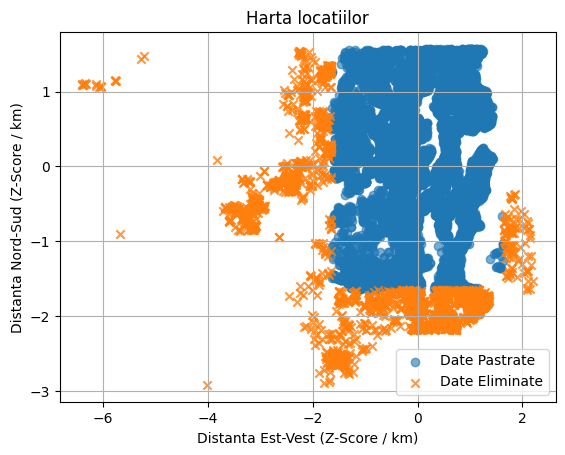

In [13]:
# Plot harta
X = distance_xy[:, 0]  # Distanța Est-Vest (Longitude)
Y = distance_xy[:, 1]  # Distanța Nord-Sud (Latitude)

# Separarea punctelor in funcție de masca de outlieri definită anterior
X_clean = X[~outlier_mask]
Y_clean = Y[~outlier_mask]
X_outliers = X[outlier_mask]
Y_outliers = Y[outlier_mask]

# Plot
plt.scatter(X_clean, Y_clean, alpha=0.6, label='Date Pastrate')
plt.scatter(X_outliers,Y_outliers, alpha=0.8, marker='x', label='Date Eliminate')
plt.title('Harta locatiilor')
plt.xlabel('Distanta Est-Vest (Z-Score / km)')
plt.ylabel('Distanta Nord-Sud (Z-Score / km)')
plt.legend()
plt.grid()
plt.show()

In [14]:
# the function implements limits for examples to be removed

# defines Z-score limits for features
def def_lim_z(limit_z, data_in):

    list_out = []
    _,_,z = z_score(data_in) 
    for i in range(z.shape[0]):  
        if z[i] <= -limit_z or z[i] >= limit_z :
            list_out.append(i)
    return z, list_out



# create list on problematic lines


list_out = []

# ~90%
list_out.extend(dist_yx_list_out)

z_price, z_price_list_out = def_lim_z(1.645, data_clean['price'])
list_out.extend(z_price_list_out)

z_bedrooms, z_bedrooms_list_out = def_lim_z(1.645, data_clean['bedrooms'])
list_out.extend(z_bedrooms_list_out)

z_bathrooms, z_bathrooms_list_out = def_lim_z(1.645, data_clean['bathrooms'])
list_out.extend(z_bathrooms_list_out)

z_sqft_living, z_sqft_living_list_out = def_lim_z(1.645, data_clean['sqft_living'])
list_out.extend(z_sqft_living_list_out)

z_sqft_lot, z_sqft_lot_list_out = def_lim_z(1.645, data_clean['sqft_lot'])
list_out.extend(z_sqft_lot_list_out)

z_floors, z_floors_list_out = def_lim_z(1.645, data_clean['floors'])
list_out.extend(z_floors_list_out)

# ~ 80 %


z_bedrooms_floors, z_bedrooms_floors_list_out = def_lim_z(1.28, data_clean['bedrooms']/data_clean['floors'])
list_out.extend(z_bedrooms_floors_list_out)

z_sqft_living_living15, z_sqft_living_living15_list_out = def_lim_z(1.28, (data_clean['sqft_living'] / data_clean['sqft_living15']))
list_out.extend(z_sqft_living_living15_list_out)

z_sqft_lot_lot15, z_sqft_lot_lot15_list_out = def_lim_z(1.28, (data_clean['sqft_lot'] / data_clean['sqft_lot15']))
list_out.extend(z_sqft_lot_lot15_list_out)

z_sqft_living_bedrooms, z_sqft_living_bedrooms_list_out = def_lim_z(1.28, (data_clean['sqft_living'] / data_clean['bedrooms']))
list_out.extend(z_sqft_living_bedrooms_list_out)

z_sqft_lot_living, z_sqft_lot_living_list_out = def_lim_z(1.28, (data_clean['sqft_lot'] / data_clean['sqft_living']))
list_out.extend(z_sqft_lot_living_list_out)


print(len(set(list_out)))

11897


In [15]:
# delete problematic lines from clean_data
for i in set(list_out):
        data_clean = data_clean.drop(i)
data_clean = data_clean.reset_index(drop=True)

print(data_clean.shape)
data_clean.head()

(9698, 17)


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,354450,4,2.75,2140,9920,2.0,3,8,2140,0,1993,0,98001,47.3529,122.274,2130,9920
1,295000,3,2.50,1940,10350,1.0,3,7,1420,520,1979,0,98001,47.3385,122.256,1810,7800
2,332000,3,2.25,2120,14915,1.0,3,9,1720,400,1979,0,98001,47.3524,122.285,2320,13100
3,215000,3,2.00,1760,9282,1.0,5,7,1100,660,1947,0,98001,47.3413,122.290,1730,7500
4,367950,4,2.50,3030,9500,2.0,3,8,3030,0,1989,0,98001,47.3511,122.287,2650,9500


In [16]:
# create function on

def plot_comp_dataset(initial_data, after_data, item):
    
    plt.figure(figsize=(20,5))
    plt.subplot(1, 2, 1)
    plt.hist(initial_data)
    plt.title(f'The initial distribution for {item}')
    plt.xlabel('standard deviation')
    plt.ylabel('number of elements')
    plt.grid()
    
    _,_,z_item = z_score(after_data)
    
    plt.subplot(1, 2, 2)
    plt.hist(z_item)
    plt.title(f'Distribution after cleaning for {item}')
    plt.xlabel('standard deviation')
    plt.ylabel('number of elements')
    
    plt.grid()
    plt.show()

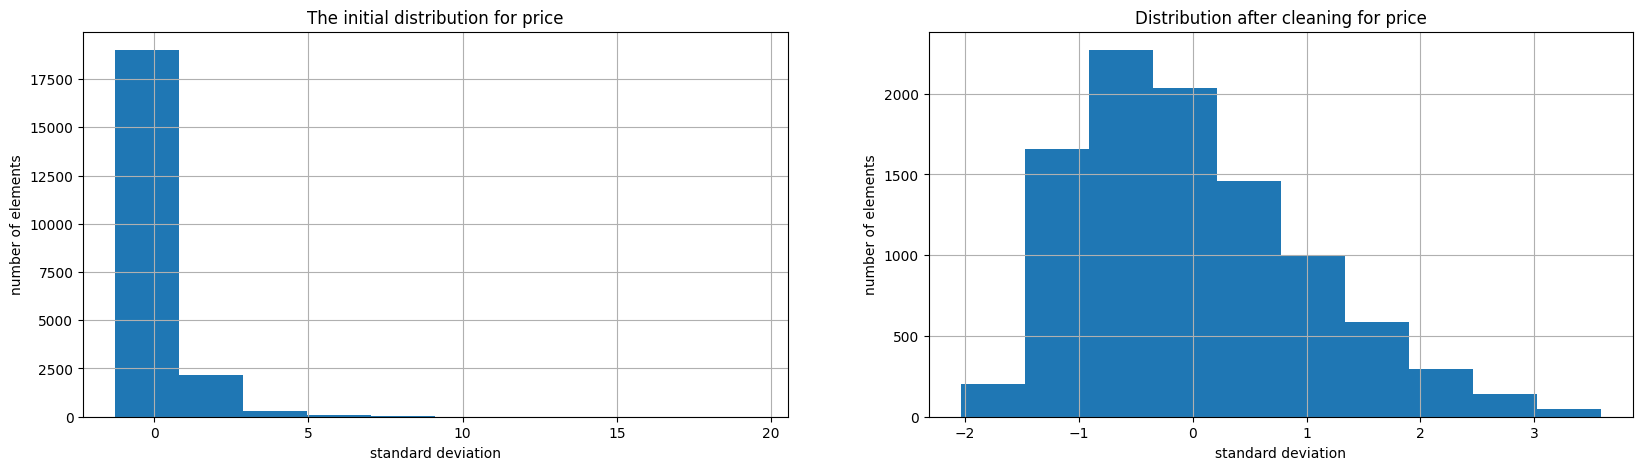

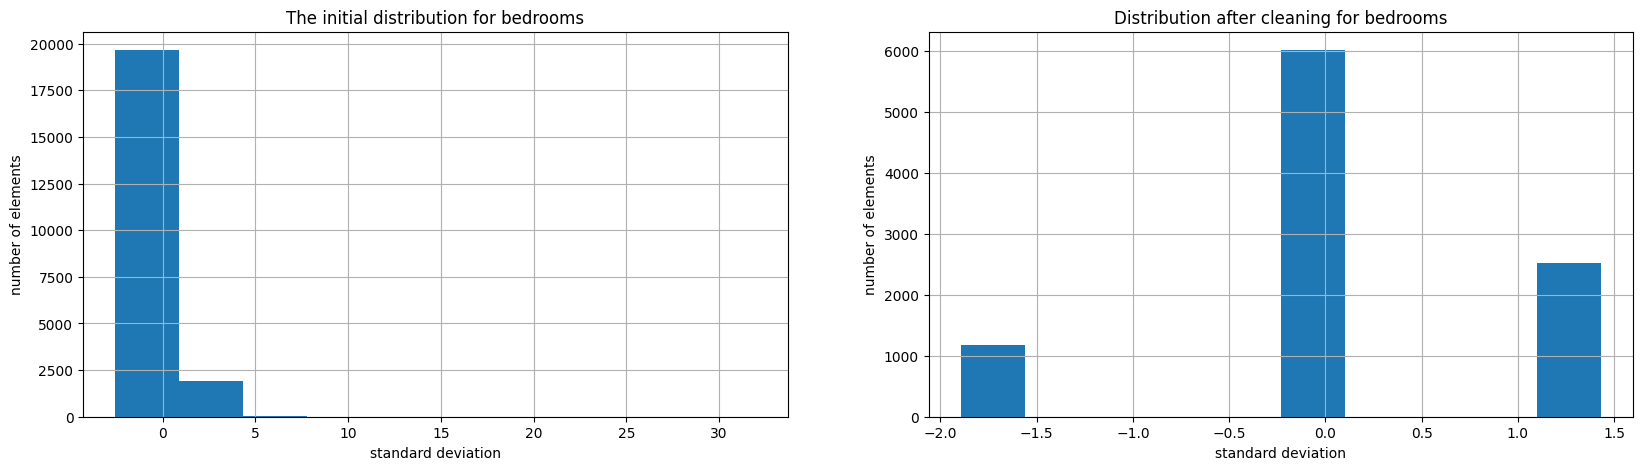

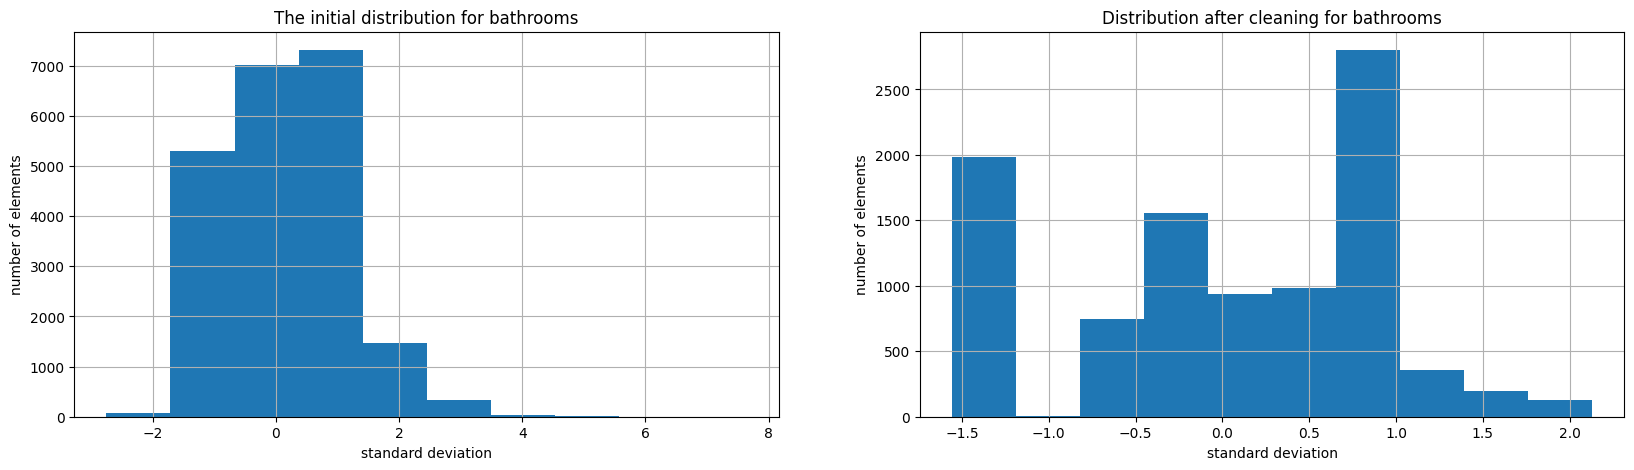

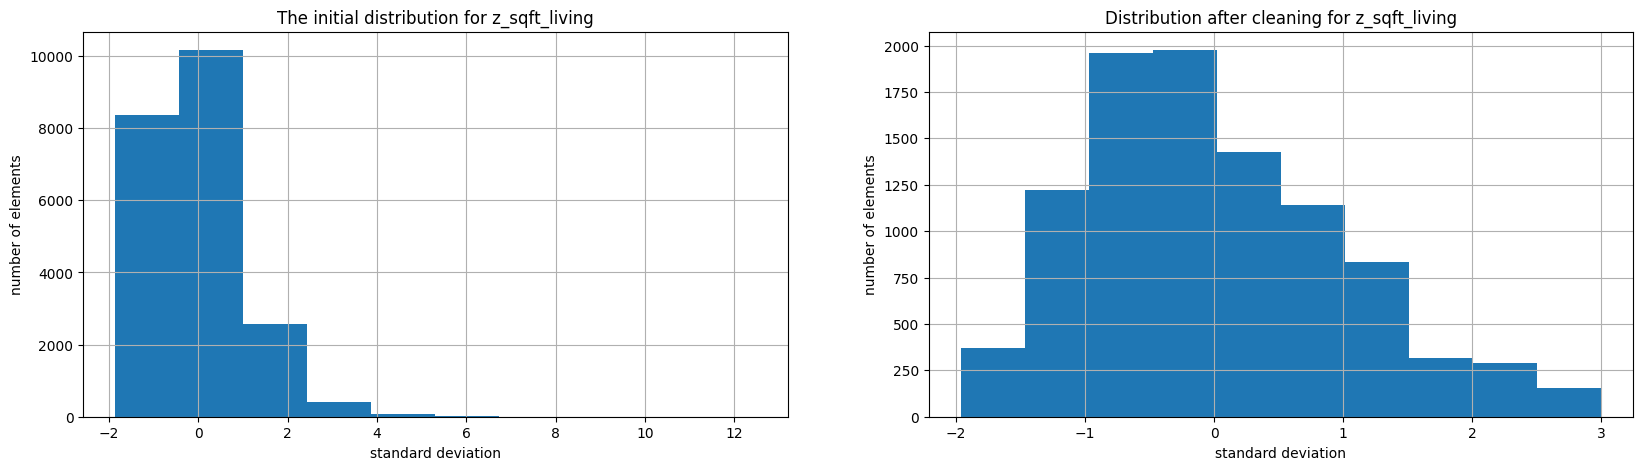

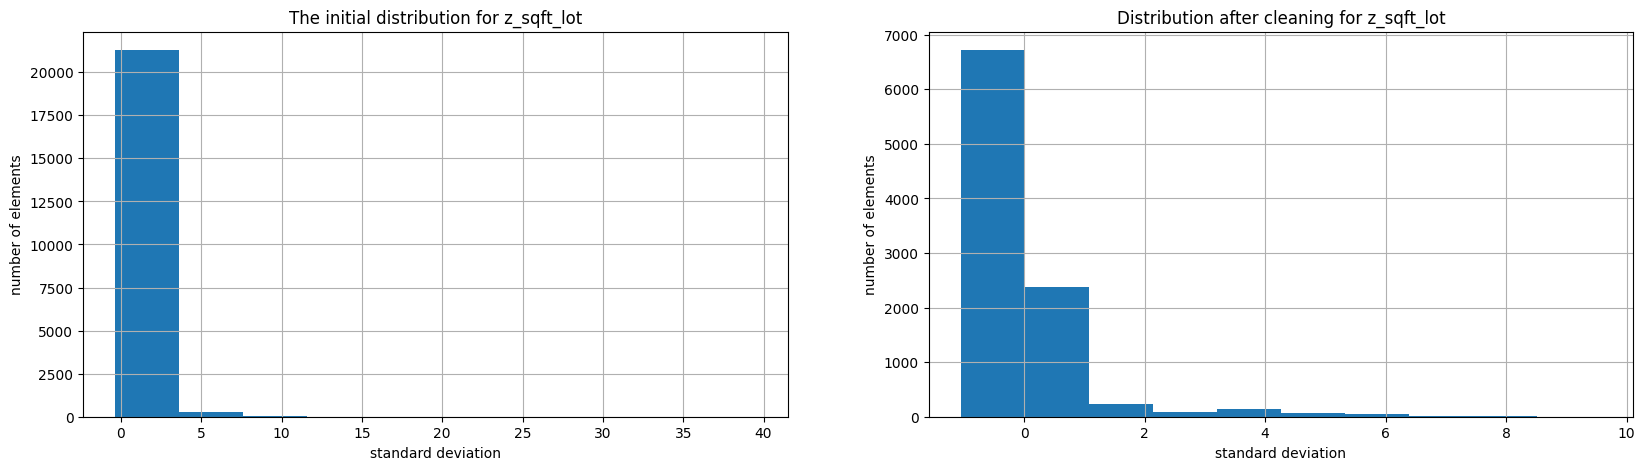

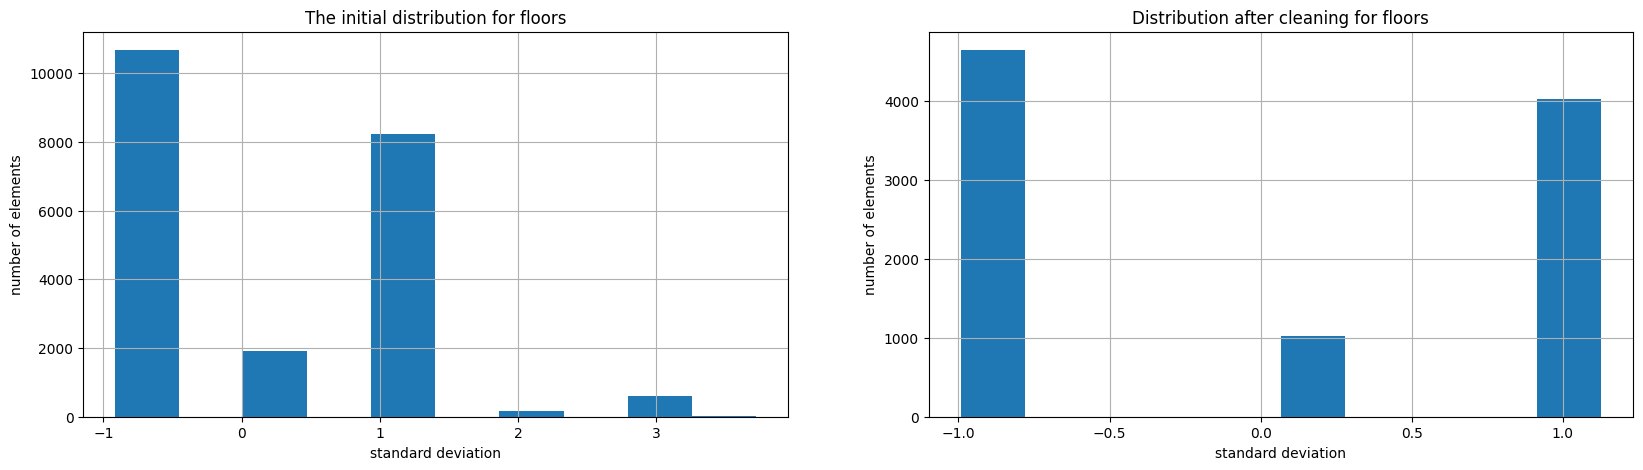

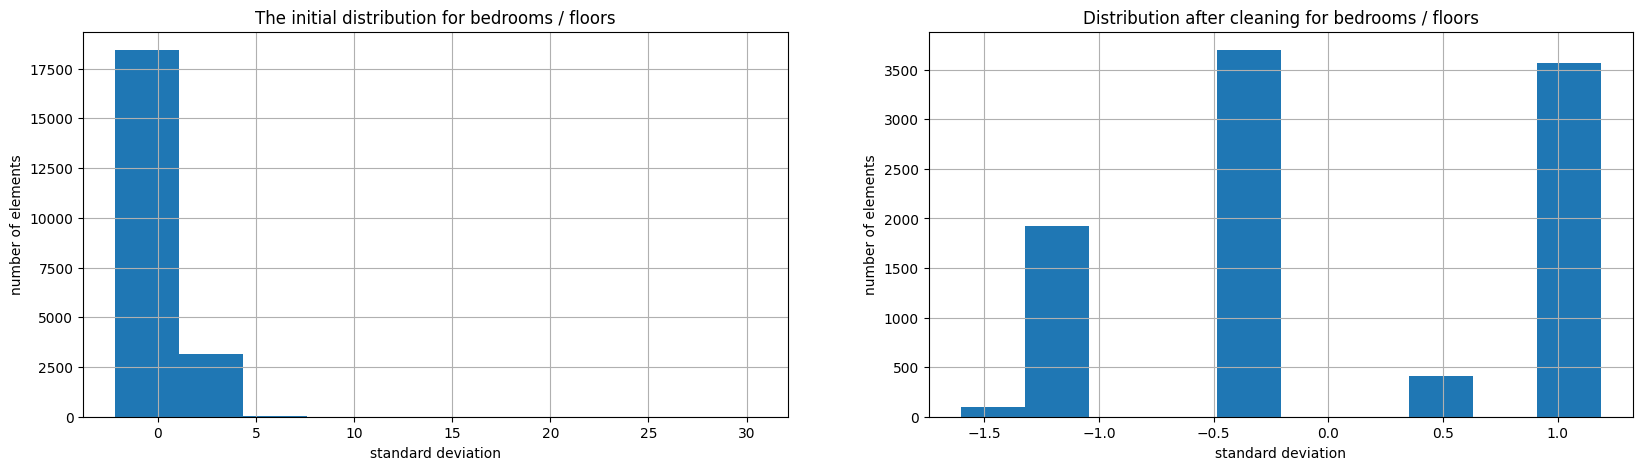

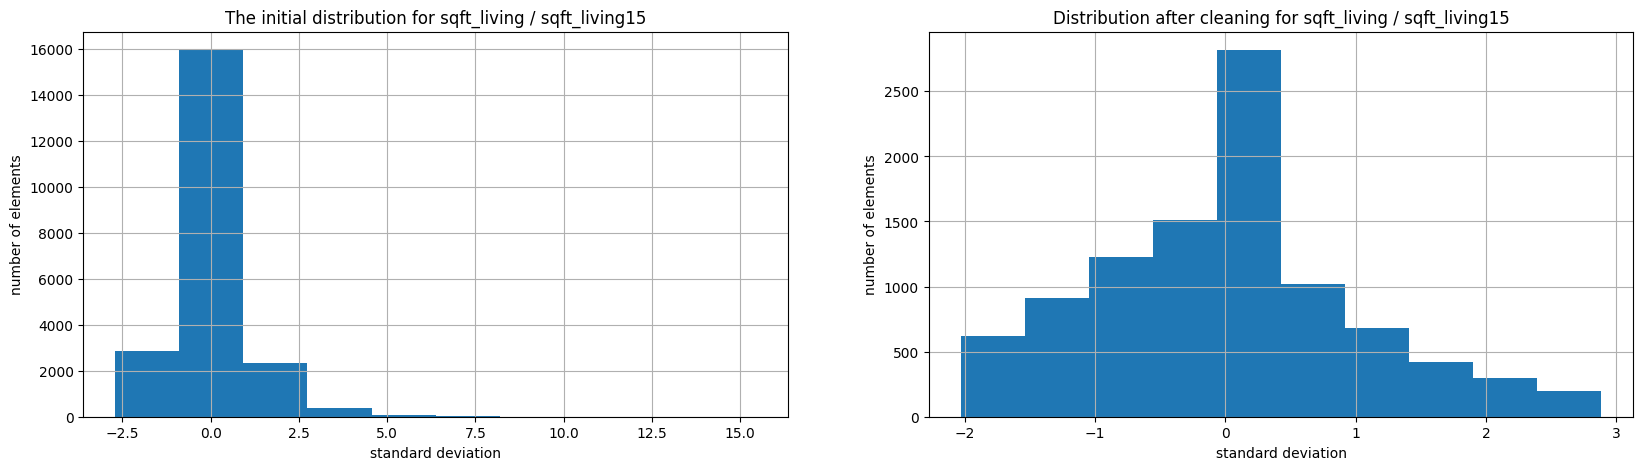

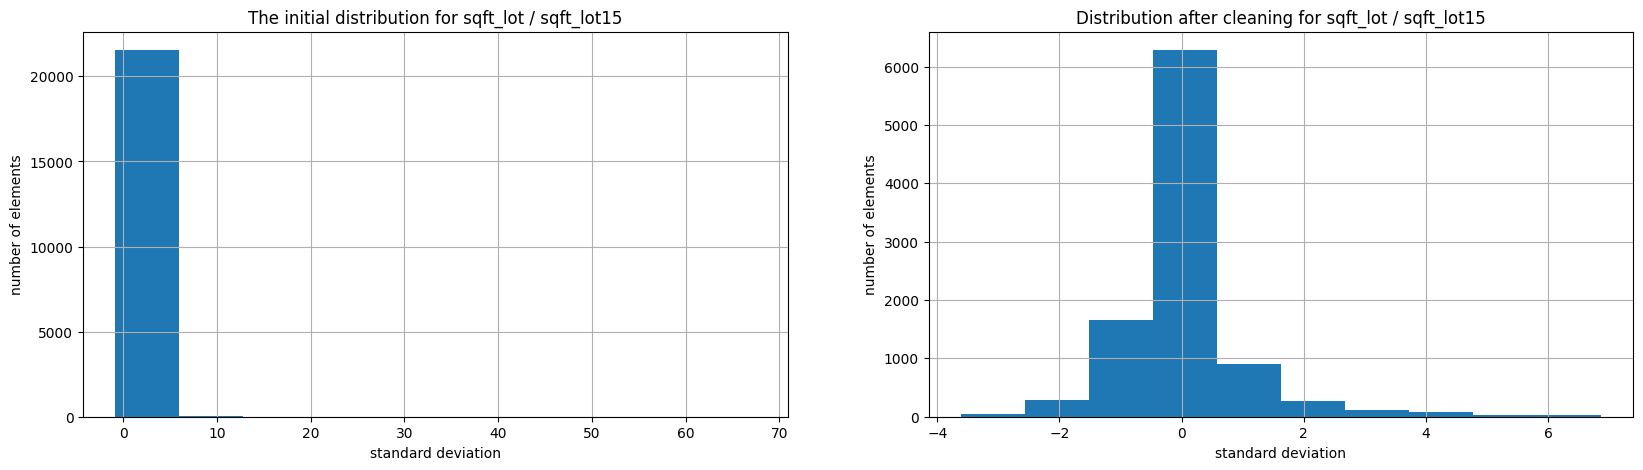

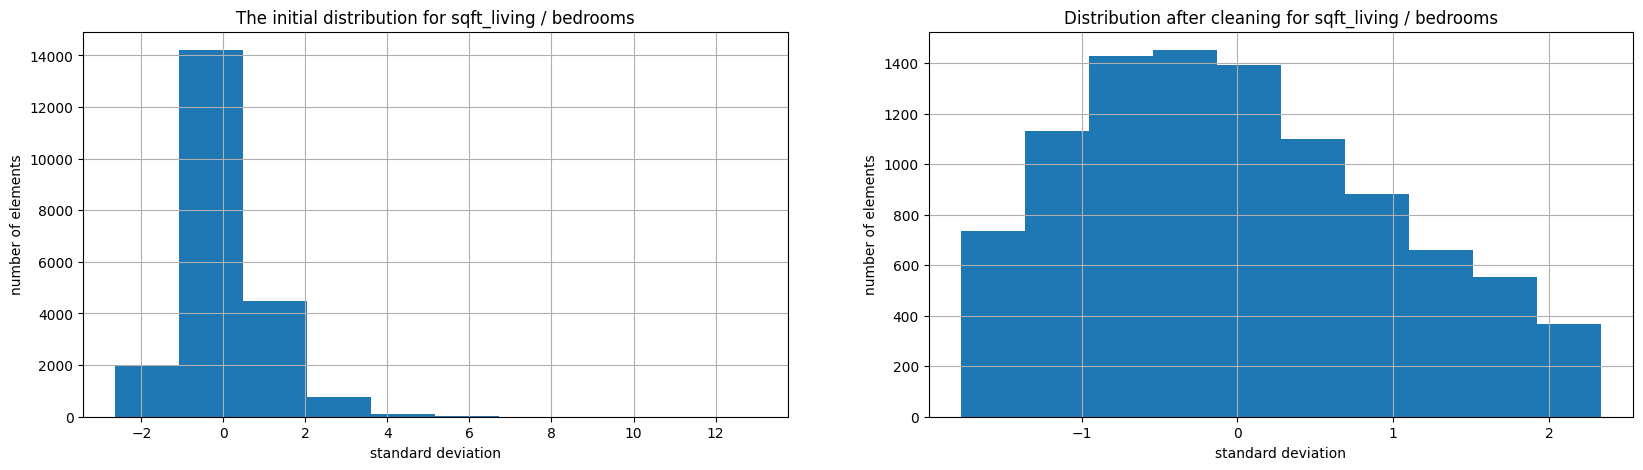

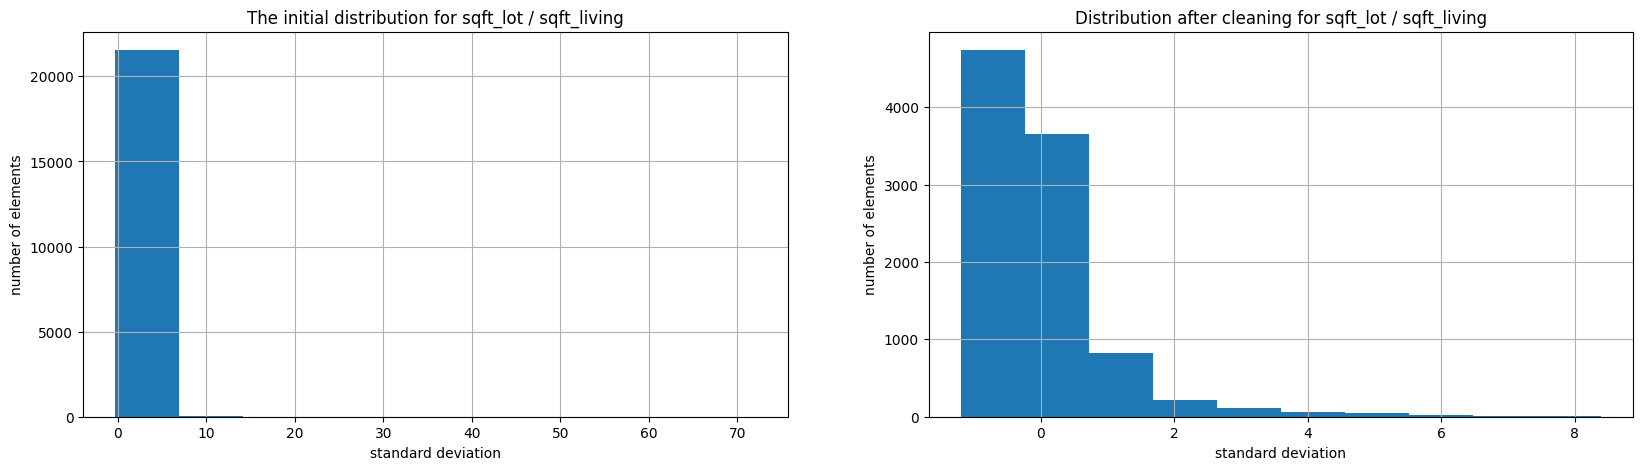

In [17]:
# execute the plotting function
plot_comp_dataset(z_price, (data_clean['price']),'price')
plot_comp_dataset(z_bedrooms, (data_clean['bedrooms']),'bedrooms')
plot_comp_dataset(z_bathrooms, (data_clean['bathrooms']),'bathrooms')
plot_comp_dataset(z_sqft_living, (data_clean['sqft_living']),'z_sqft_living')
plot_comp_dataset(z_sqft_lot, (data_clean['sqft_lot']),'z_sqft_lot')
plot_comp_dataset(z_floors, (data_clean['floors']),'floors')
plot_comp_dataset(z_bedrooms_floors, (data_clean['bedrooms']/data_clean['floors']),'bedrooms / floors')
plot_comp_dataset(z_sqft_living_living15, (data_clean['sqft_living'] / data_clean['sqft_living15']),'sqft_living / sqft_living15')
plot_comp_dataset(z_sqft_lot_lot15, (data_clean['sqft_lot'] / data_clean['sqft_lot15']),'sqft_lot / sqft_lot15')
plot_comp_dataset(z_sqft_living_bedrooms, (data_clean['sqft_living'] / data_clean['bedrooms']),'sqft_living / bedrooms')
plot_comp_dataset(z_sqft_lot_living, (data_clean['sqft_lot'] / data_clean['sqft_living']),'sqft_lot / sqft_living')

In [18]:
data_clean.to_csv('data_clean.csv', index=False)